<img alt="Finance Scenarios" src="/assets/images/projects/financescenarios/banner.png" width="100%" />


# Finance Scenarios -- 1. Getting Started

Where could interest rates, inflation and the stock market be five years from now? Nobody knows, and a single
forecast hides how wide the range of answers really is. In this notebook we let Finance Scenarios draw 500 possible
futures for the US economy, each fitted to real market data, and then we read them: what the typical future looks
like, how far the good and bad ones stray from it, and whether we can trust the run.

**Finance Scenarios** is an open-source *economic scenario generator*: it simulates many possible scenarios for
interest rates, inflation, stocks, credit, currencies, commodities and more, fitted to real market and economic data
through the [Finance Toolkit](https://github.com/JerBouma/FinanceToolkit). It has two parts that work on their own:
the scenario generator, which this notebook and the next one cover, and a portfolio layer (notebooks 3 and 4) that
puts an investment mix through scenarios once they exist.

## Installation

```
pip install financescenarios
```

To get the most out of it, you need an API key from [FinancialModelingPrep](/fmp) for the price histories behind
stock markets, Treasury yields and commodities. A free [FRED key](https://fred.stlouisfed.org/docs/api/api_key.html)
is optional and adds US corporate bond spreads and commercial property prices. Pass both the way the Finance Toolkit
takes them, as below, or leave them out to read them from the `FINANCIAL_MODELING_PREP_API_KEY` and `FRED_API_KEY`
environment variables or a `.env` file. `set_log_level("INFO")` prints every step while it works; by default only
warnings are printed.

In [1]:
import polars as pl

from financescenarios import Scenarios, list_presets, load_profiles, set_log_level

pl.Config.set_tbl_width_chars(200)  # wide enough that long factor names are not wrapped
pl.Config.set_fmt_str_lengths(60)
set_log_level("WARNING")  # the default; "INFO" shows every download and fit

## Step 1: decide what to simulate

Before we simulate anything, we answer two questions. How far ahead, how often and how many scenarios? And which
parts of the economy? Each answer is a small text file that ships with the package: a *settings* profile for the
first and a *factor set* for the second. `list_presets` shows the options, starting with the settings.

In [2]:
list_presets(kind="settings")

kind,id,use_with,name,description
str,str,str,str,str
"""settings""","""default""","""Scenarios.from_profiles(settings=""default"")""","""Default""","""2,000 scenarios, one step a month, five years ahead, fitted …"
"""settings""","""goes""","""Scenarios.from_profiles(settings=""goes"")""","""NAIC GOES""","""Default, but fitted on history since 2019 only; pair it with…"
"""settings""","""long_horizon""","""Scenarios.from_profiles(settings=""long_horizon"")""","""Long Horizon""","""Default with 500 scenarios instead of 2,000, so multi-decade…"
"""settings""","""wilkie""","""Scenarios.from_profiles(settings=""wilkie"")""","""Wilkie 1986""","""Default, fitted on 1995 to 2019 only, as the wilkie set need…"


We take `default`: 2,000 scenarios, one step a month, five years ahead. Next, the factor sets, which decide
what gets simulated.

In [2]:
list_presets(kind="factor-sets")

kind,id,use_with,name,description
str,str,str,str,str
"""factor-sets""","""ahlgrim""","""Scenarios.from_profiles(factor_set=""ahlgrim"")""","""Ahlgrim 2005""","""The six factors of Ahlgrim, D'Arcy and Gorvett (2005): short…"
"""factor-sets""","""broad""","""Scenarios.from_profiles(factor_set=""broad"")""","""Broad""","""Everything this project can simulate, across many countries:…"
"""factor-sets""","""core""","""Scenarios.from_profiles(factor_set=""core"")""","""Core""","""The US, the euro area and the UK, with global equities, gold…"
"""factor-sets""","""default""","""Scenarios.from_profiles(factor_set=""default"")""","""Default""","""Core, with interest rates anchored to EIOPA's official forwa…"
"""factor-sets""","""goes""","""Scenarios.from_profiles(factor_set=""goes"")""","""NAIC GOES""","""US Only, with the short rate's long-run level set to the NAI…"
"""factor-sets""","""hibbert""","""Scenarios.from_profiles(factor_set=""hibbert"")""","""Hibbert 2001""","""The two-factor model of Hibbert, Mowbray and Turnbull (2001)…"
"""factor-sets""","""private_markets""","""Scenarios.from_profiles(factor_set=""private_markets"")""","""Private Markets""","""US Only plus listed stand-ins for private equity, infrastruc…"
"""factor-sets""","""us_only""","""Scenarios.from_profiles(factor_set=""us_only"")""","""US Only""","""The United States only: its rates, inflation, unemployment a…"
"""factor-sets""","""wilkie""","""Scenarios.from_profiles(factor_set=""wilkie"")""","""Wilkie 1986""","""The original Wilkie (1986) actuarial model: inflation, divid…"


To keep the first run quick, we pick `us_only`: the United States' rates, inflation, unemployment and stock
market, plus the currencies, commodities and other factors every set shares. `Scenarios.from_profiles` combines the two
choices. Building it checks the configuration without downloading anything yet, and `load_profiles` lets us look
inside the same combination.

In [3]:
scenarios = Scenarios.from_profiles(
    settings="default",
    factor_set="us_only",
    api_key="FINANCIAL_MODELING_PREP_KEY",  # replace with your actual API key
    fred_api_key="FRED_KEY",  # optional, replace with your actual FRED key or leave it out
)

config = load_profiles(settings_id="default", factor_set_id="us_only")
engine = config.engine
print(f"start {config.start_date}, {engine.n_steps} {engine.frequency} steps, {engine.n_simulations} scenarios")
print(f"{len(config.interest_rates)} interest rates, {len(config.equities)} equity, {len(config.fx)} currencies")

start 2026-01-01, 60 monthly steps, 2000 scenarios
2 interest rates, 1 equity, 9 currencies


The plan is in place: 60 monthly steps from January 2026, two US interest rates (a short and a long one), one
stock market and nine currencies.

## Step 2: simulate

`simulate()` does three things in one go. It *calibrates* every variable, which means fitting its model to that
variable's own history. It measures how the variables have moved together (their *correlations*), so that in the
scenarios, too, stocks, rates and inflation move together the way they did in the past. Then it draws the scenarios at
random, which is called a *Monte Carlo simulation*. We ask for 500 scenarios instead of 2,000 to keep this quick.

In [4]:
result = scenarios.simulate(n_simulations=500)

print(f"{result.n_simulations} scenarios x {len(result.dates)} dates, from {result.dates[0]} to {result.dates[-1]}")
print("equities:", result.factors("equities"))
print("interest rates:", result.factors("interest_rates"))

500 scenarios x 61 dates, from 2026-01-01 to 2031-01-01
equities: ['us_broad']
interest rates: ['united_states_short_rate', 'united_states_long_rate']


We now have 500 scenarios, each 61 dates long, from January 2026 to January 2031. That is a lot of numbers,
so we start with a summary.

## Step 3: the overview

`describe()` gives one row per variable: where it starts (`initial`), where it ends on average after five years
(`terminal_mean`), and the range most scenarios end in. Numbers are yearly percentages written as decimals, so `0.034`
is 3.4%. For anything with a price, such as stocks, that is the *annualized return*: the average yearly growth from
today to the end date.

The range uses *percentiles*. `terminal_q05` is the 5th percentile: 5% of the scenarios, or 1 in 20, end below it.
`terminal_q95` is the 95th: 1 in 20 end above it. Nine in ten scenarios end between the two.

In [5]:
result.describe()

factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""united_states_inflation""","""Inflation — United States""","""inflation""","""rate""",0.034,0.025401,-0.001332,0.052833
"""united_states_short_rate""","""Short Rate — United States""","""interest_rates""","""rate""",0.0404,0.029343,0.010343,0.049107
"""united_states_long_rate""","""Long Rate — United States""","""interest_rates""","""rate""",0.0523,0.035747,0.01808,0.053197
"""united_states_unemployment""","""Unemployment — United States""","""unemployment""","""rate""",0.041,0.056524,0.021971,0.087043
"""us_broad""","""US Broad — Equity""","""equities""","""annualized""",null,0.101774,-0.034065,0.222693
…,…,…,…,…,…,…,…
"""rate_level""","""Yield Curve — Level""","""yield_curve""","""rate""",0.057026,0.043146,0.027029,0.059814
"""rate_slope""","""Yield Curve — Slope""","""yield_curve""","""rate""",-0.017109,-0.021056,-0.046657,0.007285
"""rate_curvature""","""Yield Curve — Curvature""","""yield_curve""","""rate""",-0.012092,-0.033135,-0.075052,0.012598


Read the first rows as a story. US inflation starts at 3.4% and averages 2.5% after five years, but 1 in 20
scenarios end below -0.1%, a mild deflation, and 1 in 20 above 5.3%. The short rate drifts down from 4.04% to 2.9% on
average, and unemployment rises from 4.1% to 5.7%. US stocks return 10.2% a year on average, while the worst 1 in 20
scenarios lose more than 3.4% a year.

Rates and inflation drift because of *mean reversion*: they can wander, but their models pull them back toward a
long-run level fitted on history. We come back to those levels in step 7.

An average after five years hides how we got there. How does the spread of the stock return develop over time?

## Step 4: follow one variable over time

`summary_statistics` follows one variable date by date. Next to the mean it gives the spread (`std`, the standard
deviation), the *standard error* (`se`, how precisely 500 scenarios pin the mean down) and the percentiles, written
as *quantiles*: `q0.05` is the 5th percentile and `q0.5` the median, the scenario in the middle. Here are the last five
months for US stocks.

In [6]:
result.summary_statistics("us_broad").tail()

date,mean,std,se,q0.05,q0.25,q0.5,q0.75,q0.95
date,f64,f64,f64,f64,f64,f64,f64,f64
2030-09-01,0.102572,0.081537,0.003646,-0.028611,0.044446,0.10964,0.156682,0.233887
2030-10-02,0.101771,0.081252,0.003634,-0.028522,0.043113,0.110811,0.155029,0.23633
2030-11-01,0.102044,0.080484,0.003599,-0.026233,0.04922,0.108353,0.155082,0.225882
2030-12-02,0.101978,0.079285,0.003546,-0.029774,0.048755,0.104766,0.158173,0.225316
2031-01-01,0.101774,0.078762,0.003522,-0.034065,0.048492,0.10481,0.156318,0.222693


At the five-year mark, the median stock return is 10.5% a year against a mean of 10.2%, and half of all
scenarios land between 4.8% and 15.6%. The standard error is 0.35 points, so 500 scenarios pin the average down well:
the uncertainty is in the spread between scenarios, far more than in the average itself.

`horizon_summary` gives the same reading at chosen horizons. Here: the short rate and inflation after one, three and
five years.

In [7]:
result.horizon_summary([1, 3, 5], factors=["united_states_short_rate", "united_states_inflation"])

factor,horizon,date,mean,std,q0.05,q0.25,q0.5,q0.75,q0.95
str,f64,date,f64,f64,f64,f64,f64,f64,f64
"""united_states_short_rate""",1.0,2027-01-01,0.037543,0.006801,0.025835,0.03314,0.037825,0.042022,0.047972
"""united_states_short_rate""",3.0,2029-01-01,0.032749,0.010195,0.015076,0.025483,0.033118,0.039384,0.049262
"""united_states_short_rate""",5.0,2031-01-01,0.029343,0.011603,0.010343,0.021749,0.028952,0.036527,0.049107
"""united_states_inflation""",1.0,2027-01-01,0.030346,0.013076,0.00854,0.021491,0.030381,0.039737,0.050464
"""united_states_inflation""",3.0,2029-01-01,0.026769,0.017083,-0.000749,0.015605,0.027247,0.037695,0.052844
"""united_states_inflation""",5.0,2031-01-01,0.025401,0.016541,-0.001332,0.014094,0.02564,0.036827,0.052833


The range widens the further ahead we look. After one year, nine in ten short-rate scenarios sit between
2.6% and 4.8%; after five years, between 1.0% and 4.9%. Inflation widens the same way, from 0.9% to 5.0% after one
year to -0.1% to 5.3% after five.

## Step 5: open up the scenarios themselves

Every summary so far comes from the individual scenarios, and sometimes we need those directly, for example to feed
our own model. `to_dataframe` gives one row per scenario and one column per date, in the same units as `describe()`.
For stocks that is the annualized return from the start to each date, so the first date is empty.

In [8]:
equity_paths = result.to_dataframe("us_broad")
equity_paths.select(equity_paths.columns[:6]).head()

scenario,2026-01-01,2026-01-31,2026-03-03,2026-04-02,2026-05-03
i64,f64,f64,f64,f64,f64
0,null,-0.305938,-0.018479,-0.118171,-0.130928
1,null,0.117445,0.270861,0.061517,0.064993
2,null,0.186513,0.222111,0.144201,0.212675
3,null,-0.013196,0.284268,0.464774,0.426568
4,null,-0.456071,-0.399301,-0.256384,-0.22987


Scenario 1 is up at every date shown, while scenarios 0 and 4 are down at every one. The numbers swing
widely in these first months, because a single month's move is scaled up to a yearly rate. A table of 500 rows is
hard to take in, though, so we draw it.

## Step 6: see it

`plot` draws a *fan chart* by default: the line is the median scenario, the darker band holds the middle half of the
scenarios and the lighter band nine in ten.

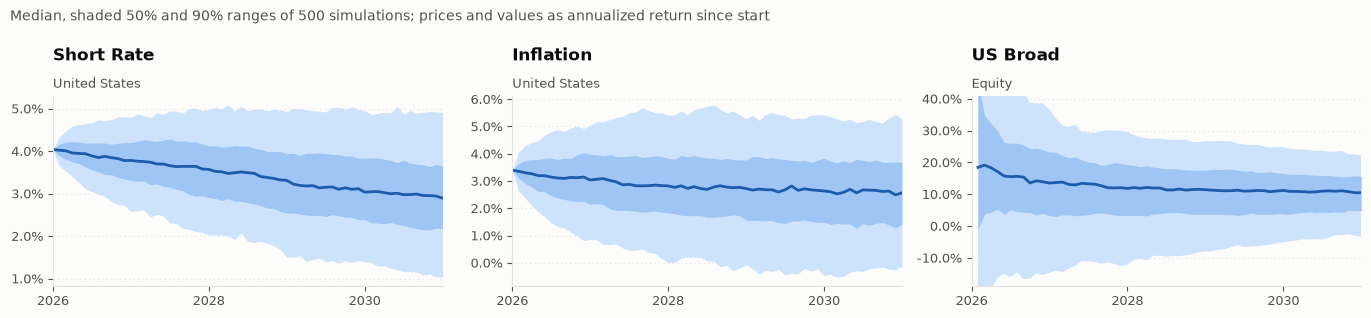

In [9]:
result.plot(["united_states_short_rate", "united_states_inflation", "us_broad"])

Each fan tells its own story. The short rate drifts down while its range widens. Inflation's range opens up
in the first two years and then holds its width. The stock fan starts very wide and narrows, for the reason we saw in
the table: early on, one month counts as a whole year.

To see where stocks end up, `kind="distribution"` draws a histogram of the five-year outcome.

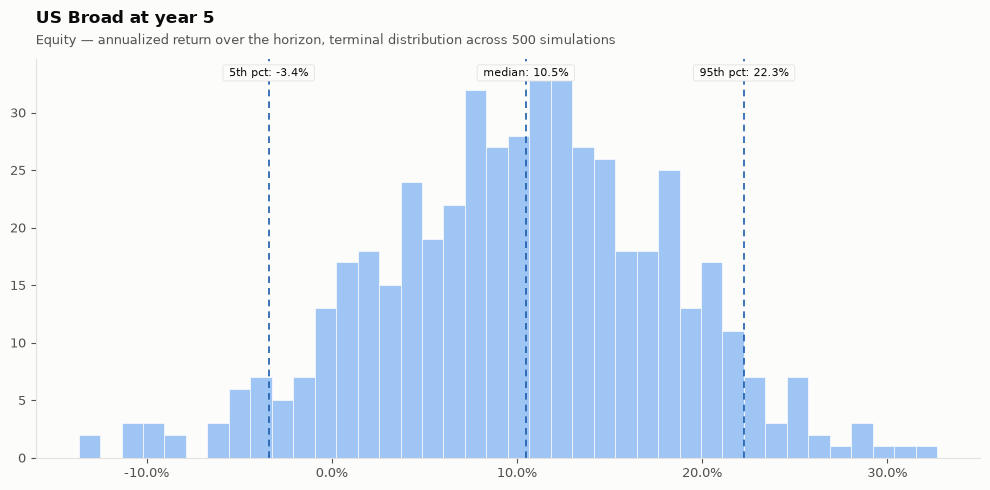

In [10]:
result.plot("us_broad", kind="distribution")

The histogram marks the median at 10.5% a year, with the 5th and 95th percentiles at -3.4% and 22.3%. Most
scenarios cluster around the middle, and a tail of them loses money over the full five years.

Before we build on any of this, one question remains: did the simulation do what its own models promise?

## Step 7: check the run

For every mean-reverting variable, the model implies a long-run average and spread. `diagnose()` sets the simulated
values after five years next to those long-run values, and `within_tolerance` says whether they are close.

In [11]:
result.diagnose()

factor,simulated_mean,theoretical_mean,simulated_std,theoretical_std,within_tolerance
str,f64,f64,f64,f64,bool
"""united_states_inflation""",0.025401,0.026605,0.016541,0.01735,true
"""united_states_short_rate""",0.029343,0.014271,0.011603,0.01512,false
"""united_states_long_rate""",0.035747,0.031595,0.010825,0.011078,true
"""united_states_unemployment""",0.056524,0.056313,0.020344,0.019825,true
"""gold""",8.614196,10.197092,0.380356,0.701,false
…,…,…,…,…,…
"""rate_level""",0.043146,0.040426,0.010102,0.010622,true
"""rate_slope""",-0.021056,-0.021396,0.016693,0.017149,true
"""rate_curvature""",-0.033135,-0.033864,0.025267,0.025442,true


Inflation, the long rate and unemployment match well: inflation's simulated mean of 2.5% sits next to a
long-run 2.7%. The short rate does not, at 2.9% against a long-run 1.4%. It started at 4.04% and reverts slowly, so five
years are not long enough to get all the way there. Among the rows shown, gold and real estate are flagged too, and those are worth a
closer look before you rely on them.

`scenarios.validate(result)` runs a wider set of checks, each with a plain-language explanation of what it tests.

In [12]:
scenarios.validate(result)

check,status,detail,meaning
str,str,str,str
"""Every factor calibrated""","""pass""","""every factor calibrated""","""A factor whose fit fails (for example, no mean reversion in …"
"""Parameters in a plausible range""","""pass""","""every long-run level and half-life in range""","""A rate that settles outside -5% to 25% a year, or takes unde…"
"""Valid correlation matrix""","""pass""","""25 factors, smallest eigenvalue 9.77e-09, symmetric True, un…","""The correlations that link the factors must form a valid mat…"
"""Simulation reproduces the correlations""","""warn""","""largest gap 0.153 (us_broad/spy_yield); pairs with a linked …","""The simulated factors should move together the way they were…"
"""Simulated volatility matches history""","""pass""","""22 factors compared, median ratio 1.01""","""How much each factor moves per year in the simulation, again…"
"""Every path is finite""","""pass""","""25 factors, all finite""","""A NaN or infinite value anywhere means a step function broke…"


Five of the six checks pass. The one warning says some pairs of variables move together a little
differently in the simulation than in the fitted correlations, by at most 0.153, between US stocks and `spy_yield`
(the dividend yield of the S&P 500 fund). Simulated volatility matches history with a median ratio of 1.01, and all 25
factors stay finite. That is enough to work with.

## Going further: build a configuration yourself

The profiles are the quick way in. To choose every variable yourself, you can write the same configuration in Python.
Here we build a small run: the US short rate, US inflation and the broad US stock market (the SPY fund), ten years
ahead in monthly steps. US unemployment comes along without being listed, because interest rates, inflation, equities
and unemployment are always simulated.

In [13]:
from datetime import date

from financescenarios import ScenariosConfig
from financescenarios.config.config_model import EngineConfig, EquityConfig, InflationConfig, InterestRateConfig

small_config = ScenariosConfig(
    start_date=date(2026, 1, 1),
    interest_rates=[InterestRateConfig(name="us_short_rate", country="United States", currency="USD")],
    inflation=[InflationConfig(name="inflation", country="United States", currency="USD")],
    equities=[EquityConfig(name="us_broad", ticker="SPY", currency="USD")],
    engine=EngineConfig(n_simulations=500, n_steps=120, frequency="monthly", seed=42),
)

small_result = Scenarios.from_config(small_config).simulate()
small_result.describe()

factor,label,category,metric,initial,terminal_mean,terminal_q05,terminal_q95
str,str,str,str,f64,f64,f64,f64
"""inflation""","""Inflation — United States""","""inflation""","""rate""",0.034,0.022991,-0.010725,0.05423
"""us_short_rate""","""Short Rate — United States""","""interest_rates""","""rate""",0.0404,0.040507,0.018726,0.064953
"""unemployment""","""Unemployment — United States""","""unemployment""","""rate""",0.041,0.038238,0.033306,0.043127
"""us_broad""","""US Broad — Equity""","""equities""","""annualized""",null,0.128945,0.049525,0.212442


With four variables, a ten-year horizon and a fixed seed, the numbers differ from the run above: the short
rate now averages 4.05% at the end, close to where it started, and stocks return 12.9% a year on average. Every choice
in the configuration shapes the result, so compare runs only when they share their setup.

## Step 8: keep the result

Calibrating takes time and live data changes every day, so we store a run we want to use again. `scenarios.save`
writes the scenarios, the settings and the calibration into a folder of their own, and `read_run` reads them back
without downloading or simulating anything. A temporary folder keeps this example tidy; normally you would pass
something like `"results/"`.

In [14]:
import tempfile

import numpy as np

from financescenarios import read_run

with tempfile.TemporaryDirectory() as folder:
    path = scenarios.save(result, folder)
    reloaded = read_run(path)
    same = all(np.allclose(reloaded.paths[name], result.paths[name]) for name in result.factor_names)
    print(f"saved as {path.name}: {reloaded.n_simulations} scenarios, {len(reloaded.factor_names)} factors")
    print(f"identical to the original: {same}")

saved as 20261009T073744Z-ff10e40d: 500 scenarios, 25 factors
identical to the original: True


The reloaded run is identical to the original.

## What we learned

- A run combines a settings profile (how far ahead, how often, how many scenarios) with a factor set (what to simulate).
- `describe()` gives the overview and percentiles give the range around it. In this run, US stocks return 10.2% a year
  on average over five years, while 1 in 20 scenarios lose more than 3.4% a year.
- The range of rates and inflation widens with the horizon, while mean reversion pulls them toward long-run levels.
- `diagnose()` and `validate()` tell us how far to trust a run, and `save` and `read_run` keep it.

All of this describes an economy that behaves the way its history suggests. What if inflation jumps toward 9%, or
stocks, jobs and rates fall at the same time? That is the next notebook, [**2. Regimes**](/projects/financescenarios/regimes-notebook).
After that, **3. Portfolio** puts an investment mix through the scenarios and **4. Portfolio Analysis** tests it on
history.